# AskMyBookmark — Orchestrator Pattern POC

This notebook builds a **LangGraph orchestrator** (supervisor pattern) for searching starred GitHub repositories.

## Architecture

The key insight guiding this design: **keyword extraction → synonym generation is always a fixed,
sequential pipeline** — there is no routing decision to make. Exposing them as separate agent tools
would let the LLM call them out of order or skip one. Instead they form a deterministic
**Query Prep sub-workflow** that always runs first.

The **Supervisor** is the only true agent: it reads the (now-enriched) state and decides which
retriever to invoke.

```
User Query
    │
    ▼
┌─────────────────────────────────────────┐
│       Query Prep (deterministic)        │
│   keyword_extractor → synonym_generator │
└─────────────────────────────────────────┘
    │
    ▼
┌─────────────────────────────────────────┐
│   Supervisor Agent (binary LLM router)  │
│   Decides: lexical | ensemble           │
└─────────────────────────────────────────┘
    │                         │
    ▼ (pure keywords only)    ▼ (default — everything else)
lexical_search           ensemble_search
(MultiMatch BM25          (EnsembleRetriever:
 + legacy BM25,            MultiMatch BM25
 union-dedup)              + Qdrant dense, RRF)
    │                         │
    └───────────┬─────────────┘
                ▼
          merge_results
          (dedup pool of up to RETRIEVER_K=15 candidates)
                │
                ▼
         classify_curated
         (gpt-4o-mini batch classifier, 8+8 few-shot examples;
          writes is_curated_llm bool into each doc's metadata)
                │
                ▼
         filter_results
         (remove curated lists if include_curated=False;
          primary: is_curated_llm, fallback: BM25 score ≥ 4.0,
          safety net prevents empty result sets)
                │
                ▼
         rerank_results
         (listwise gpt-4o-mini reranker → trim to top_k)
                │
                ▼
         generate_answer
                │
                ▼
             Response
```

## Routing Heuristic

| Route | When to use |
|---|---|
| `ensemble` | **Default.** Any natural language, conceptual, or mixed query |
| `lexical` | Query is *literally just keywords* — no sentence structure (e.g. `"pytorch transformers"`) |

## State Shape

| Field | Populated by | Used by |
|---|---|---|
| `query` | user input | `keyword_extractor`, `ensemble_search`, `generate_answer` |
| `keywords` | `keyword_extractor` | `synonym_generator`, `lexical_search`, `ensemble_search` |
| `expansions` | `synonym_generator` | (debugging / display) |
| `bm25_terms` | `synonym_generator` | `lexical_search`, `ensemble_search` |
| `route` | `supervisor` | conditional edge routing |
| `include_curated` | `supervisor` | `classify_curated`, `filter_results` (keep or remove curated-list repos) |
| `bm25_results` | `lexical_search` / `ensemble_search` | `merge_results` |
| `vector_results` | (always empty — fused results go in `bm25_results`) | `merge_results` |
| `merged_results` | `merge_results` | `generate_answer` |
| `answer` | `generate_answer` | end user |


## 1. Imports & Environment Setup

In [1]:
import os
import pickle
import re
import uuid
from functools import partial
from typing import List, Dict, Any, Literal

import nest_asyncio
import numpy as np
import pandas as pd
import nltk
from dotenv import load_dotenv
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from pydantic import BaseModel, Field, ConfigDict
from textacy import preprocessing
from typing import TypedDict

from langchain.retrievers import EnsembleRetriever
from langchain_community.retrievers import BM25Retriever
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langchain_core.retrievers import BaseRetriever
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from langgraph.graph import StateGraph, START, END
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams
from searcharray import SearchArray

nest_asyncio.apply()

# load environment variables — try notebooks/.env first (local dev), then root .env
for _env_path in ["notebooks/.env", ".env"]:
    if os.path.exists(_env_path):
        load_dotenv(_env_path)
        break

# download NLTK data if not already present
for _pkg in ["punkt", "stopwords", "wordnet", "punkt_tab"]:
    nltk.download(_pkg, quiet=True)

print("Imports OK")

Imports OK


## 2. Shared State

All nodes read from and write to a single `OrchestratorState` dict.  LangGraph merges the
partial dicts returned by each node into this shared state, so each node only needs to
return the keys it modifies.

In [2]:
class OrchestratorState(TypedDict):
    # ── Input ────────────────────────────────────────────────────────────────
    query: str                     # original user query (verbatim)

    # ── Query Prep (populated by deterministic sub-workflow) ─────────────────
    keywords: List[str]            # signal-bearing terms extracted from query
    expansions: List[Dict]         # per-keyword synonym objects (for inspection)
    bm25_terms: List[str]          # flat synonym list used to expand BM25 query

    # ── Supervisor ───────────────────────────────────────────────────────────
    route: str                     # "lexical" | "ensemble"
    include_curated: bool          # whether to include curated-list repos in results

    # ── Retrieval results ────────────────────────────────────────────────────
    bm25_results: List[Document]
    vector_results: List[Document]
    merged_results: List[Document]

    # ── User-controlled output size ───────────────────────────────────────────
    # Set at invocation time; defaults to 10 if not provided.
    # Retrievers always over-fetch (RETRIEVER_K candidates) internally.
    top_k: int

    # ── Final output ─────────────────────────────────────────────────────────
    answer: str

## 3. Query Prep — Deterministic Sub-Workflow

These two nodes **always run sequentially** before the supervisor sees the state.  There is no
routing decision here — the sequence is fixed in the graph edges.

### Why this is a workflow, not agent tools

If `keyword_extractor` and `synonym_generator` were exposed as separate tools to the supervisor,
an LLM could call them out of order, forget one, or call `synonym_generator` directly on raw
natural language.  Making them deterministic graph nodes eliminates that class of failure entirely.

### Design note: keyword extraction is idempotent on keyword-only queries

The extractor strips conversational filler and returns signal-bearing terms.  For a query that is
*already* just keywords (e.g. `"pytorch transformers"`), the extractor returns them unchanged.
This means we never need a separate "is this natural language?" classifier — just always run both
nodes.

In [3]:
# ── Structured output schemas ─────────────────────────────────────────────────

class KeywordExtractionOutput(BaseModel):
    keywords: List[str] = Field(
        description="Keywords extracted from the user query suitable for BM25 lexical search."
    )


class KeywordExpansion(BaseModel):
    keyword: str = Field(description="The original extracted keyword.")
    synonyms: List[str] = Field(
        description="Synonyms and closely related technical terms for this keyword "
                    "in the context of GitHub repos."
    )


class SynonymExpansionOutput(BaseModel):
    expansions: List[KeywordExpansion] = Field(
        description="Per-keyword synonym expansions."
    )


# ── System prompts ─────────────────────────────────────────────────────────────

KEYWORD_EXTRACTION_SYSTEM_PROMPT = """\
You are a search query keyword extractor for AskMyBookmark -- a conversational search \
assistant that helps people search through their starred GitHub repos. \
When given a user query, extract only the keywords that carry lexical search signal: \
repo names, technology names, programming languages, domain terms, and action verbs. \
Strip conversational filler, pronouns, and stopwords.\
Ignore extracting words related to repositories, repos, or GitHub in general.\
Ignore extracting words related to favorites or starred if related to repositories or GitHub in general.\
"""

SYNONYM_EXPANSION_SYSTEM_PROMPT = """\
You are a search term expander for AskMyBookmark -- a search assistant over starred GitHub repos. \
Given a list of search keywords, generate relevant synonyms and closely related technical terms \
for each keyword in the context of software, science, technology and GitHub repositories. \
Avoid duplicating the original keywords in the synonyms list.\
"""

# ── LLMs with structured output ───────────────────────────────────────────────

_base_llm = ChatOpenAI(model="gpt-4o-mini")
_keyword_extractor_llm = _base_llm.with_structured_output(KeywordExtractionOutput)
_synonym_generator_llm = _base_llm.with_structured_output(SynonymExpansionOutput)


# ── Graph nodes ───────────────────────────────────────────────────────────────

def keyword_extractor(state: OrchestratorState) -> dict:
    """Extract signal-bearing keywords from the raw user query."""
    response: KeywordExtractionOutput = _keyword_extractor_llm.invoke([
        SystemMessage(content=KEYWORD_EXTRACTION_SYSTEM_PROMPT),
        HumanMessage(content=state["query"]),
    ])
    return {"keywords": response.keywords}


def synonym_generator(state: OrchestratorState) -> dict:
    """Expand each keyword with synonyms; flatten into a single BM25 term list."""
    response: SynonymExpansionOutput = _synonym_generator_llm.invoke([
        SystemMessage(content=SYNONYM_EXPANSION_SYSTEM_PROMPT),
        HumanMessage(content=str(state["keywords"])),
    ])
    bm25_terms = [syn for exp in response.expansions for syn in exp.synonyms]
    return {
        "expansions": [exp.model_dump() for exp in response.expansions],
        "bm25_terms": bm25_terms,
    }


print("Query prep nodes defined")

Query prep nodes defined


## 4. Data Loading & Index Building

We reuse the exact same retriever setup from `retrievers.ipynb`:

- **`MultiMatchBM25Retriever`** — a custom LangChain retriever wrapping SearchArray's per-field
  BM25 with boost weights (`repo` × 3, `topics` × 2, `description` × 1.5, `content` × 1.0).
- **Qdrant in-memory dense retriever** — OpenAI `text-embedding-3-small` embeddings stored in
  a local Qdrant instance, queried with cosine similarity.

Both retrievers are built once at notebook startup and shared across graph invocations.

In [4]:
# ── Text pre-processing (mirrors retrievers.ipynb / ask_my_bookmark.py) ────────

MAX_CHARACTERS = 30_000
NAMESPACE = uuid.NAMESPACE_URL


def strip_markdown(text: str) -> str:
    """Remove common Markdown syntax while keeping inner text and emojis."""
    text = re.sub(r"^#{1,6}\s*", "", text, flags=re.MULTILINE)
    text = re.sub(r"`([^`]+)`", r"\1", text)
    text = re.sub(r"\*{1,2}([^*]+)\*{1,2}", r"\1", text)
    text = re.sub(r"_{1,2}([^_]+)_{1,2}", r"\1", text)
    text = re.sub(r"\[([^\]]+)\]\([^)]+\)", r"\1", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text


def make_normalize_text_pipeline(*, unicode_form: str = "NFC"):
    return preprocessing.make_pipeline(
        strip_markdown,
        preprocessing.remove.html_tags,
        preprocessing.normalize.bullet_points,
        preprocessing.normalize.quotation_marks,
        partial(preprocessing.normalize.unicode, form=unicode_form),
        preprocessing.normalize.whitespace,
    )


_normalize_text = make_normalize_text_pipeline()


def repo_to_uuid(repo_name: str) -> str:
    return str(uuid.uuid5(NAMESPACE, repo_name))


def normalize_docs(docs: List[Dict[str, Any]]) -> str:
    content_str = "".join(doc["content"] + "\n\n" for doc in docs)
    truncated = content_str[:MAX_CHARACTERS] if len(content_str) > MAX_CHARACTERS else content_str
    return _normalize_text(truncated)


def preprocess_text(text: str | None) -> List[str]:
    """Tokenizer used by SearchArray BM25 — lowercase, remove stopwords, lemmatize."""
    if text is None:
        return []
    text = text.lower()
    text = re.sub(r"[^a-zA-Z]", " ", text)
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words("english"))
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(w) for w in tokens]


print("Text preprocessing helpers defined")

Text preprocessing helpers defined


In [5]:
# ── MultiMatchBM25Retriever (from retrievers.ipynb) ────────────────────────────

def multi_match_search(
    query: str,
    df: pd.DataFrame,
    columns: List[str],
    boosts: Dict[str, float] | None = None,
) -> pd.DataFrame:
    """BM25 multi-field search with per-field boost weights and dismax scoring."""
    if boosts is None:
        boosts = {}
    boost_values = {col: boosts.get(col, 1.0) for col in columns}

    tokenized_queries = {
        col: df[col].array.tokenizer(query)
        for col in columns
    }

    field_scores = {
        col: np.asarray([df[col].array.score(term) for term in tokenized_queries[col]])
             * boost_values[col]
        for col in columns
    }

    num_terms = max((len(s) for s in field_scores.values()), default=0)
    if num_terms == 0:
        result = df.copy()
        result["score"] = 0.0
        return result

    best_term_scores = []
    for term_idx in range(num_terms):
        term_scores = [
            field_scores[col][term_idx]
            for col in columns
            if term_idx < len(field_scores[col])
        ]
        best_term_scores.append(np.max(term_scores, axis=0))

    result = df.copy()
    result["score"] = np.sum(best_term_scores, axis=0)
    return result.sort_values("score", ascending=False)


class MultiMatchBM25Retriever(BaseRetriever):
    """LangChain-compatible retriever wrapping SearchArray multi-field BM25."""

    model_config = ConfigDict(arbitrary_types_allowed=True)

    search_df: pd.DataFrame
    columns: List[str]
    boosts: Dict[str, float]
    k: int = 10

    def _get_relevant_documents(
        self,
        query: str,
        *,
        run_manager: CallbackManagerForRetrieverRun,
    ) -> List[Document]:
        results = multi_match_search(
            query=query,
            df=self.search_df,
            columns=self.columns,
            boosts=self.boosts,
        )
        top_k = results[results["score"] > 0].head(self.k)
        return [
            Document(
                page_content=row["content"],
                metadata={
                    "id":          row["id"],
                    "repo":        row["repo"],
                    "description": row["description"],
                    "topics":      row["topics"],
                    "score":       float(row["score"]),
                },
            )
            for _, row in top_k.iterrows()
        ]


print("MultiMatchBM25Retriever defined")

MultiMatchBM25Retriever defined


In [6]:
# ── Load cached GitHub data ───────────────────────────────────────────────────

with open("../data/cached/github_data.pkl", "rb") as f:
    starred_repo_data = pickle.load(f)

print(f"Loaded {len(starred_repo_data)} starred repos")

# ── Build per-field search DataFrame ─────────────────────────────────────────

search_df = pd.DataFrame([
    {
        "id":          repo_to_uuid(repo["repo"]),
        "repo":        repo["repo"],
        "description": repo.get("description") or "",
        "topics":      " ".join(repo.get("topics", [])),
        "content":     f"Topics: {','.join(repo.get('topics', []))}\n" + normalize_docs(repo["docs"]),
    }
    for repo in starred_repo_data
])

# index each field with SearchArray for BM25 scoring
search_df["repo_idx"]        = SearchArray.index(search_df["repo"],        tokenizer=preprocess_text)
search_df["description_idx"] = SearchArray.index(search_df["description"], tokenizer=preprocess_text)
search_df["topics_idx"]      = SearchArray.index(search_df["topics"],      tokenizer=preprocess_text)
search_df["content_idx"]     = SearchArray.index(search_df["content"],     tokenizer=preprocess_text)

print(f"search_df built: {len(search_df)} rows")

Loaded 2049 starred repos
2026-03-17 00:09:31,802 - searcharray.indexing - INFO - Indexing begins w/ 4 workers
2026-03-17 00:09:31,803 - searcharray.indexing - INFO - 0 Batch Start tokenization
2026-03-17 00:09:31,803 - searcharray.indexing - INFO - Tokenizing 2049 documents
2026-03-17 00:09:33,270 - searcharray.indexing - INFO - Tokenization -- vstacking
2026-03-17 00:09:33,270 - searcharray.indexing - INFO - Tokenization -- DONE
2026-03-17 00:09:33,271 - searcharray.indexing - INFO - Inverting docs->terms
2026-03-17 00:09:33,272 - searcharray.indexing - INFO - Encoding positions to bit array
2026-03-17 00:09:33,274 - searcharray.indexing - INFO - Batch tokenization complete
2026-03-17 00:09:33,274 - searcharray.indexing - INFO - (main thread) Processing 1 batch results
2026-03-17 00:09:33,275 - searcharray.indexing - INFO - Indexing from tokenization complete
2026-03-17 00:09:33,276 - searcharray.indexing - INFO - Indexing begins w/ 4 workers
2026-03-17 00:09:33,276 - searcharray.ind

In [7]:
# ── Compute curated-list BM25 score (for document metadata) ──────────────────
#
# Repos that are themselves "awesome lists" get a boosted score stored in
# metadata so the answer generator can note it if relevant.

CURATED_QUERY = "awesome curated lists"
curated_results = multi_match_search(
    query=CURATED_QUERY,
    df=search_df,
    columns=["repo_idx", "topics_idx", "description_idx", "content_idx"],
    boosts={"repo_idx": 3.0, "topics_idx": 2.0, "description_idx": 1.5, "content_idx": 1.0},
)
curated_score_by_id = dict(
    zip(curated_results["id"], curated_results["score"].astype(float))
)

# ── Build LangChain Document objects (shared by both retrievers) ──────────────

documents = [
    Document(
        page_content=f"Topics: {','.join(repo.get('topics', []))}\n" + normalize_docs(repo["docs"]),
        metadata={
            "id":                (id_ := repo_to_uuid(repo["repo"])),
            "repo":              repo["repo"],
            "description":       repo.get("description") or "",
            "topics":            repo.get("topics", []),
            "language":          repo.get("language"),
            "doc_source":        repo.get("doc_source"),
            "stars":             repo.get("stars"),
            "url":               repo.get("url"),
            "curated_list_bm25": curated_score_by_id.get(id_, 0.0),
        },
    )
    for repo in starred_repo_data
]

# ── Over-fetch constant ───────────────────────────────────────────────────────
#
# All retrievers fetch RETRIEVER_K candidates so the listwise reranker has a
# larger pool to work from before trimming to the user's top_k.  RETRIEVER_K
# should always be >= the maximum top_k a user might request.

RETRIEVER_K = 15

# ── Curated-list filtering thresholds ────────────────────────────────────────
#
# CURATED_FILTER_THRESHOLD: curated_list_bm25 scores at or above this are
#   treated as "definitely a curated list" and are hard-filtered from results
#   when the supervisor sets include_curated=False.
#
# CURATED_LABEL_THRESHOLD: scores at or above this are flagged as "Likely" a
#   curated list in the LLM context.  Lower than the filter threshold so the
#   answer LLM and reranker get a signal on borderline repos.
#
# Note: BM25 is an imperfect proxy — some curated lists score below 2.0 if
#   they don't use canonical "awesome / curated / list" keywords.  Labels are
#   intentionally probabilistic (Yes / Likely / Most likely not).

CURATED_FILTER_THRESHOLD = 4.0
CURATED_LABEL_THRESHOLD  = 2.0

# ── MultiMatchBM25 retriever ──────────────────────────────────────────────────

bm25_retriever = MultiMatchBM25Retriever(
    search_df=search_df,
    columns=["repo_idx", "topics_idx", "description_idx", "content_idx"],
    boosts={
        "repo_idx":        3.0,
        "topics_idx":      2.0,
        "description_idx": 1.5,
        "content_idx":     1.0,
    },
    k=RETRIEVER_K,
)

# ── Qdrant in-memory dense retriever ─────────────────────────────────────────

print("Building Qdrant index — this may take a minute...")

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
qdrant_client = QdrantClient(":memory:")
qdrant_client.create_collection(
    collection_name="ask_my_bookmark",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)
vector_store = QdrantVectorStore(
    client=qdrant_client,
    collection_name="ask_my_bookmark",
    embedding=embeddings,
)
vector_store.add_documents(documents)
dense_retriever = vector_store.as_retriever(search_kwargs={"k": RETRIEVER_K})

# ── Ensemble retriever (RRF fusion of BM25 + dense) ──────────────────────────
#
# EnsembleRetriever combines results from both retrievers using Reciprocal Rank
# Fusion (RRF). Unlike running them sequentially and merging manually, RRF
# re-ranks by inverse rank position, giving a principled combined ranking.
# Used by the `ensemble_search` node when the supervisor routes to "ensemble".

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
)

# ── Legacy BM25 retriever (standard LangChain TF-IDF over full document text) ─
#
# Uses a different scoring algorithm than MultiMatchBM25Retriever — operates on
# the full document content rather than per-field boosted scoring.  Running both
# BM25 methods together for lexical search maximises recall: they surface
# different sets of candidate repos, as observed in retrievers.ipynb.

legacy_bm25_retriever = BM25Retriever.from_documents(documents)
legacy_bm25_retriever.k = RETRIEVER_K

print("All retrievers ready (MultiMatch BM25, legacy BM25, dense, ensemble)")

Building Qdrant index — this may take a minute...
All retrievers ready (MultiMatch BM25, legacy BM25, dense, ensemble)


## 5. Search Nodes

Two search nodes cover the two routing outcomes:

| Node | Retriever(s) | Query input |
|---|---|---|
| `lexical_search` | `MultiMatchBM25Retriever` + `BM25Retriever` (merged) | `keywords` + `bm25_terms` joined as one expanded string |
| `ensemble_search` | `EnsembleRetriever` (MultiMatch BM25 + Qdrant dense via RRF) | expanded BM25 query |

### Why two BM25 methods in `lexical_search`?

`MultiMatchBM25Retriever` uses per-field boost weights (repo name × 3, topics × 2, etc.) and
SearchArray's scoring.  The legacy `BM25Retriever` uses standard LangChain TF-IDF over the full
document content.  They surface **different** candidate repos — running both together and
deduplicating maximises lexical recall, as observed in `retrievers.ipynb`.

A single `lexical_search` node runs both internally (no routing decision needed) and merges
via union-dedup, preserving MultiMatch results first.

### Why `ensemble_search` is the default

`EnsembleRetriever` fuses MultiMatch BM25 + Qdrant dense via **Reciprocal Rank Fusion (RRF)**:
each document scores `1 / (rank + k)` from each leg, summed and re-ranked.  This covers
*both* exact-term precision and semantic recall in a single pass — better than either alone
for natural language queries.  The supervisor routes here unless the query is pure keywords.

> **Note on query string for ensemble:** `EnsembleRetriever` passes the same query string to
> all child retrievers.  We pass the **expanded BM25 query** (keywords + synonyms) so the
> BM25 leg gets full term expansion benefit.  The dense leg is robust enough that synonym
> terms in the query string do not meaningfully hurt embedding quality.

In [8]:
def _build_expanded_query(state: OrchestratorState) -> str:
    """Join extracted keywords + synonyms into a single expanded query string for BM25."""
    all_terms = state["keywords"] + state["bm25_terms"]
    return " ".join(all_terms)


def lexical_search(state: OrchestratorState) -> dict:
    """Run dual-BM25 lexical search: MultiMatchBM25 + legacy BM25, merged by union-dedup.

    Both retrievers use the keyword-expanded query (original keywords + synonyms).
    MultiMatchBM25 uses per-field boost weights; legacy BM25 uses full-document
    TF-IDF.  They surface different candidates, so running both maximises recall.
    Results are merged: MultiMatch first (field-boosted precision), then any
    legacy-only results appended.
    """
    expanded_query = _build_expanded_query(state)

    multi_results = bm25_retriever.invoke(expanded_query)
    legacy_results = legacy_bm25_retriever.invoke(expanded_query)

    # union-dedup: MultiMatch first, then append legacy-only results
    seen = {doc.metadata.get("repo") for doc in multi_results}
    extra = [doc for doc in legacy_results if doc.metadata.get("repo") not in seen]

    return {"bm25_results": multi_results + extra, "vector_results": []}


def ensemble_search(state: OrchestratorState) -> dict:
    """Run EnsembleRetriever (RRF fusion of MultiMatch BM25 + Qdrant dense).

    Default route for natural language and mixed queries.  Passes the expanded
    query (keywords + synonyms) so the BM25 leg benefits from term expansion
    while the dense leg remains robust to the extra terms.
    Results stored in bm25_results so merge_results passes them through unchanged.
    """
    expanded_query = _build_expanded_query(state)
    results = ensemble_retriever.invoke(expanded_query)
    return {"bm25_results": results, "vector_results": []}


print("Search nodes defined")

Search nodes defined


## 6. Supervisor — LLM Router

The supervisor is the only agent in this graph.  It reads the enriched state (original query +
extracted keywords) and makes a **binary routing decision** via structured output:

| Route | Condition |
|---|---|
| `lexical` | Query is *literally* just keywords — no sentence structure, no natural language phrasing |
| `ensemble` | Everything else (default) — natural language, mixed, conceptual, or ambiguous queries |

This binary design keeps the supervisor's job simple and the error rate low.  `ensemble_search`
covers the vast majority of real queries; `lexical_search` is reserved for tight keyword inputs
where maximum BM25 recall is all that's needed.

Using structured output (`RouteDecision`) guarantees the node always writes a valid `route`
value that the conditional edge can act on — no string parsing required.

In [9]:
# ── Routing decision schema ───────────────────────────────────────────────────

class RouteDecision(BaseModel):
    route: Literal["lexical", "ensemble"] = Field(
        description=(
            "Search strategy to use. "
            "Choose 'lexical' ONLY when the query is literally just keywords with no "
            "sentence structure or natural language phrasing. "
            "Choose 'ensemble' for everything else — natural language, conceptual, "
            "mixed, or ambiguous queries."
        )
    )
    include_curated: bool = Field(
        description=(
            "Whether to include curated-list repositories (e.g. 'awesome-X' lists, "
            "resource roundups, link collections) in the results. "
            "Set True ONLY when the user is explicitly asking for lists, resources, "
            "collections, courses, or curated roundups "
            "(e.g. 'show me awesome lists', 'what resource collections do I have', "
            "'find me a course on X'). "
            "Set False for all other queries where the user wants a specific tool, "
            "library, or repository — not a collection of links."
        )
    )
    reasoning: str = Field(
        description="One sentence explaining the route and include_curated decisions."
    )


SUPERVISOR_SYSTEM_PROMPT = """\
You are the search router for AskMyBookmark, an assistant that searches a user's starred GitHub repos.

Given a user query and its extracted keywords, make two decisions:

## 1. Search strategy (route)

- "ensemble"  : DEFAULT. Use for any query that contains natural language, sentence structure,
                conversational phrasing, or a mix of concepts.  This covers the vast majority
                of queries and uses RRF fusion of BM25 + semantic search for best coverage.

- "lexical"   : Use ONLY when the query is literally just a list of keywords — no sentence
                structure, no verbs, no question words (e.g. "pytorch transformers cuda").
                In this case pure BM25 term matching is sufficient and preferred.

When in doubt, always prefer "ensemble".

## 2. Include curated lists (include_curated)

Curated lists are repositories that are themselves collections of links, resources, or tools
(e.g. "awesome-machine-learning", "the-incredible-pytorch", course roundups).

- Set True  : ONLY when the user explicitly asks for lists, resources, collections, courses,
              or curated roundups (e.g. "show me awesome lists for deep learning",
              "what resource collections do I have", "find me a course").

- Set False : For all other queries where the user wants a specific tool, library, framework,
              or implementation — not a collection of links.  This is the default.
"""

_supervisor_llm = ChatOpenAI(model="gpt-4o-mini").with_structured_output(RouteDecision)


def supervisor(state: OrchestratorState) -> dict:
    """LLM router: decides search strategy (route) and curated-list inclusion."""
    user_message = (
        f"Query: {state['query']}\n"
        f"Extracted keywords: {state['keywords']}"
    )
    decision: RouteDecision = _supervisor_llm.invoke([
        SystemMessage(content=SUPERVISOR_SYSTEM_PROMPT),
        HumanMessage(content=user_message),
    ])
    print(
        f"[supervisor] route={decision.route!r}  "
        f"include_curated={decision.include_curated}  "
        f"reason: {decision.reasoning}"
    )
    return {"route": decision.route, "include_curated": decision.include_curated}


def route_after_supervisor(state: OrchestratorState) -> str:
    """Conditional edge function — returns the node name to visit next."""
    route_map = {
        "lexical":  "lexical_search",
        "ensemble": "ensemble_search",
    }
    return route_map[state["route"]]


print("Supervisor node defined")

Supervisor node defined


## 7. Merge, Rerank & Answer Generation

### `merge_results`

Deduplicates the over-fetched pool from the search nodes (up to `RETRIEVER_K` candidates)
into a single ordered list by union-dedup.  No trimming happens here — the full pool is
passed to the reranker.

### `rerank_results` (listwise LLM reranker)

A dedicated `gpt-4o-mini` call receives the full candidate pool and the original query and
returns a relevance-ranked ordering.  The reranker formats each candidate as a numbered
entry (repo name, description, topics, language) and asks the LLM to output the candidate
indices from most to least relevant.

**Why listwise over pairwise?**  A single LLM call handles all `n` candidates at once —
`O(1)` API calls vs `O(n²)` for full pairwise ELO.  Quality is comparable for a moderate
pool size (≤20 docs), and latency/cost are manageable.

After reranking, results are trimmed to `state["top_k"]` (default 10) before the answer
generator sees them.

### `generate_answer`

Uses the same RAG system prompt from `app/ask_my_bookmark.py` — grounding the LLM strictly
in the retrieved and reranked repository context.

In [23]:
# ── Merge node ────────────────────────────────────────────────────────────────

def merge_results(state: OrchestratorState) -> dict:
    """
    Deduplicate and merge BM25 + vector results.

    Strategy: iterate BM25 results first (precise expanded-keyword matches),
    then append any vector-only results not already seen.  This gives a merged
    list that favours lexical precision while filling in semantic coverage.
    """
    seen_repos: set = set()
    merged: List[Document] = []

    for doc in (state["bm25_results"] + state["vector_results"]):
        repo = doc.metadata.get("repo")
        if repo and repo not in seen_repos:
            seen_repos.add(repo)
            merged.append(doc)

    return {"merged_results": merged}


# ── Curated-list filter node ──────────────────────────────────────────────────

def filter_results(state: OrchestratorState) -> dict:
    """Remove curated-list repos from the candidate pool when include_curated=False.

    Primary signal:  is_curated_llm (bool) written by classify_curated — a
                     gpt-4o-mini few-shot classifier trained on 8+8 examples.
    Fallback signal: curated_list_bm25 >= CURATED_FILTER_THRESHOLD (4.0) — the
                     BM25-based score used when the LLM classifier did not run.

    A document is filtered out if EITHER signal marks it as a curated list.

    Safety net: if filtering would leave fewer than min(top_k, 3) results, skip
    the filter entirely and pass the full pool through.  This prevents empty or
    near-empty result sets when a niche query only matches curated list repos.
    """
    if state.get("include_curated", False):
        return {"merged_results": state["merged_results"]}

    candidates = state["merged_results"]
    top_k = state.get("top_k", 10)
    safety_floor = min(top_k, 3)

    filtered = [
        doc for doc in candidates
        if not doc.metadata.get("is_curated_llm", False)
        and doc.metadata.get("curated_list_bm25", 0.0) < CURATED_FILTER_THRESHOLD
    ]

    if len(filtered) < safety_floor:
        print(
            f"[filter_results] safety net triggered: only {len(filtered)} non-curated "
            f"results (floor={safety_floor}), keeping all {len(candidates)} candidates"
        )
        return {"merged_results": candidates}

    n_removed = len(candidates) - len(filtered)
    print(
        f"[filter_results] removed {n_removed} curated-list repo(s), "
        f"{len(filtered)} candidates remaining"
    )
    return {"merged_results": filtered}


# ── LLM curated-list classifier ───────────────────────────────────────────────

class _CuratedItem(BaseModel):
    index: int = Field(description="0-based index of the candidate in the input list")
    is_curated_list: bool = Field(
        description=(
            "True if the repo is a curated list/directory of external links; "
            "False if it is a real project delivering its own code, data, or content."
        )
    )
    reason: str = Field(description="Brief 5-10 word explanation for the classification")


class _CuratedClassifications(BaseModel):
    classifications: List[_CuratedItem] = Field(
        description="Classification for every candidate in the input list"
    )


CURATED_CLASSIFIER_SYSTEM_PROMPT = """\
You are a classifier that determines whether a GitHub repository is a **curated list** \
or a **real project**.

## Key Principle
A **curated list** is a repository whose primary value is aggregating links or references \
to external content (other repos, papers, tools, tutorials, courses, books). It acts as an \
index or directory.

A **real project** delivers its own original code, data, models, or written content. Even if \
it uses the words "curated", "collection", or "list" in its description, what matters is \
whether the repo IS the thing or merely points to other things.

## Examples of CURATED LISTS
[0] Repo: wsvincent/awesome-django
    Description: A curated list of awesome things related to Django
    Topics: awesome, awesome-list, django
    → CURATED: aggregates links to Django tools, packages, and tutorials.

[1] Repo: eugeneyan/applied-ml
    Description: Papers & tech blogs by companies sharing their work on data science & machine learning in production.
    Topics: applied-machine-learning, data-science, natural-language-processing
    → CURATED: aggregates external blog posts and papers; the repo itself contains no original code.

[2] Repo: Developer-Y/cs-video-courses
    Description: List of Computer Science courses with video lectures.
    Topics: algorithms, computer-science, machine-learning
    → CURATED: a directory of links to external video courses.

[3] Repo: NirDiamant/RAG_Techniques
    Description: This repository showcases various advanced techniques for Retrieval-Augmented Generation (RAG) systems.
    Topics: langchain, llm, rag, tutorials
    → CURATED: despite sounding like a project, it is a collection of tutorial notebooks — value is the curated index of examples, not a deployable tool.

[4] Repo: ossu/computer-science
    Description: Path to a free self-taught education in Computer Science!
    Topics: computer-science, curriculum, education
    → CURATED: a structured roadmap of links to external free courses; contains no original course content.

[5] Repo: ashishps1/learn-ai-engineering
    Description: Learn AI and LLMs from scratch using free resources
    Topics: ai, large-language-models, llm, machine-learning
    → CURATED: primary value is the aggregated collection of free external resources it links to.

[6] Repo: EbookFoundation/free-programming-books
    Description: Freely available programming books
    Topics: books, education, list
    → CURATED: a pure link collection; the "content" is pointers to books available elsewhere.

[7] Repo: codecrafters-io/build-your-own-x
    Description: Master programming by recreating your favorite technologies from scratch.
    Topics: programming, tutorial
    → CURATED: aggregates links to external "build your own X" tutorials; the repo is an index of those links.

## Examples of REAL PROJECTS

[8] Repo: explosion/curated-transformers
    Description: A PyTorch library of curated Transformer models and their composable components
    Topics: bert, llm, nlp, pytorch, transformer
    → REAL PROJECT: despite "curated" in the name, this IS a usable PyTorch library — the code is the value.

[9] Repo: google-deepmind/mujoco_menagerie
    Description: A collection of high-quality models for the MuJoCo physics engine, curated by Google DeepMind.
    Topics: mujoco, robotics
    → REAL PROJECT: the model files (XML/MJCF) ARE the deliverable; "curated" describes quality, not a link directory.

[10] Repo: h5bp/Front-end-Developer-Interview-Questions
     Description: A list of helpful front-end related questions you can use to interview potential candidates.
     Topics: css-questions, front-end, html-questions, interview-questions
     → REAL PROJECT: the questions themselves are the original written content — not links to external question banks.

[11] Repo: faridrashidi/kaggle-solutions
     Description: Collection of Kaggle Solutions and Ideas
     Topics: kaggle, machine-learning, solutions
     → REAL PROJECT: contains actual solution code notebooks; not links to external Kaggle submissions.

[12] Repo: openai/spinningup
     Description: An educational resource to help anyone learn deep reinforcement learning.
     Topics: deep-reinforcement-learning, machine-learning, reinforcement-learning
     → REAL PROJECT: despite "educational resource" phrasing, it contains actual RL algorithm implementations in code.

[13] Repo: huggingface/transformers
     Description: The model-definition framework for state-of-the-art machine learning models in text, vision, audio.
     Topics: deep-learning, llm, machine-learning, nlp, pytorch
     → REAL PROJECT: a full ML framework delivering original software.

[14] Repo: weaviate/weaviate
     Description: Weaviate is an open-source vector database that stores both objects and vectors.
     Topics: vector-database, vector-search, semantic-search
     → REAL PROJECT: a deployable database system with its own code.

[15] Repo: argilla-io/argilla
     Description: Argilla is a collaboration tool for AI engineers and domain experts to build high-quality datasets
     Topics: annotation-tool, llm, nlp, text-labeling
     → REAL PROJECT: a specific tool with real application code — not a link directory.

## Task
For each candidate below, classify it as a curated list or a real project.
Output JSON with a "classifications" array covering EVERY candidate index provided.
"""

_curator_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).with_structured_output(
    _CuratedClassifications
)


def classify_curated(state: OrchestratorState) -> dict:
    """Batch LLM classifier: annotates each candidate with is_curated_llm bool.

    Sends all merged_results to gpt-4o-mini in a single call using an 8+8
    few-shot prompt that teaches the key principle: a curated list aggregates
    links/references to external content; a real project delivers its own
    original code, data, or content.

    Writes 'is_curated_llm' (bool) and 'is_curated_reason' (str) into each
    document's metadata for downstream use by filter_results and _format_context.

    Skipped entirely when include_curated=True (no classification needed).
    Falls back gracefully as a no-op if the LLM call fails — filter_results
    will then rely solely on the BM25 curated_list_bm25 score.
    """
    if state.get("include_curated", False):
        return {}

    candidates = state["merged_results"]
    if not candidates:
        return {}

    candidate_lines = []
    for i, doc in enumerate(candidates):
        m = doc.metadata
        topics_str = ", ".join(m.get("topics", [])) or "none"
        candidate_lines.append(
            f"[{i}] Repo: {m.get('repo', 'unknown')}\n"
            f"     Description: {m.get('description', '') or 'N/A'}\n"
            f"     Topics: {topics_str}"
        )
    candidates_text = "\n\n".join(candidate_lines)

    try:
        result: _CuratedClassifications = _curator_llm.invoke([
            SystemMessage(content=CURATED_CLASSIFIER_SYSTEM_PROMPT),
            HumanMessage(content=f"Candidates to classify:\n\n{candidates_text}"),
        ])

        # Copy docs to avoid mutating shared state objects
        classified_docs = [
            Document(page_content=d.page_content, metadata=dict(d.metadata))
            for d in candidates
        ]
        for item in result.classifications:
            if 0 <= item.index < len(classified_docs):
                classified_docs[item.index].metadata["is_curated_llm"] = item.is_curated_list
                classified_docs[item.index].metadata["is_curated_reason"] = item.reason

        n_curated = sum(1 for item in result.classifications if item.is_curated_list)
        print(f"[classify_curated] {n_curated}/{len(candidates)} candidates flagged as curated lists")
        return {"merged_results": classified_docs}

    except Exception as exc:
        print(f"[classify_curated] fallback to BM25 signal (error: {exc})")
        return {}


# ── RAG system prompt (from ask_my_bookmark.py) ────────────────────────────────

RAG_SYSTEM_PROMPT = """You are AskMyBookmark, a personal research assistant with access to the user's GitHub starred repositories.

Your job is to help the user discover, recall, and explore repositories they have bookmarked on GitHub. You answer questions by reasoning over the retrieved repository context provided to you — not from your general knowledge of what exists on GitHub.

**Ground rules:**
- Only surface repositories that appear in the retrieved context below. Do not invent or suggest repositories that are not present in the context.
- If no retrieved repositories are relevant to the query, say so honestly and suggest the user try rephrasing or broadening their search.
- You may use your general knowledge to explain a topic or technology, but all repository recommendations must come exclusively from the retrieved context.

**Format your response as a strict numbered list from 1 to {n_results}.**
- Every number from 1 to {n_results} must appear exactly once. Do not skip any number.
- Each numbered entry must correspond to exactly one repository from the context, in the order they are listed (already ranked best-first).
- Do not add a closing paragraph summarising which repos were "most relevant" or noting that others were omitted — every entry must appear in the numbered list.

**For each numbered entry include:**
- The repository's full name as a markdown link: [owner/repo](URL)
- A brief description of what it does, in your own words.
- 1–2 sentences on *why* it is relevant to the user's query.
- Optionally: language, star count, or topics if they help the user evaluate the match.
"""

RAG_HUMAN_PROMPT_TEMPLATE = """User query: {query}

Retrieved repositories ({n_results} total, already ranked best-first):
Format your answer as a numbered list from 1 to {n_results}. Every number must appear.
{context}
"""

_rag_prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(RAG_SYSTEM_PROMPT),
    HumanMessagePromptTemplate.from_template(RAG_HUMAN_PROMPT_TEMPLATE),
])

_answer_llm = ChatOpenAI(model="gpt-4o-mini")
_rag_chain = _rag_prompt | _answer_llm


def _curated_label(m: dict) -> str:
    """Return a human-readable curated-list label for the given document metadata.

    Prefers the LLM classification (is_curated_llm) when available; falls back
    to the BM25-derived score with graded thresholds.
    """
    if "is_curated_llm" in m:
        return "Yes" if m["is_curated_llm"] else "Most likely not"
    score = m.get("curated_list_bm25", 0.0)
    if score >= CURATED_FILTER_THRESHOLD:
        return "Yes"
    if score >= CURATED_LABEL_THRESHOLD:
        return "Likely"
    return "Most likely not"


def _format_context(docs: List[Document]) -> str:
    """Serialise retrieved docs into the context block passed to the LLM."""
    parts = []
    for doc in docs:
        m = doc.metadata
        repo = m.get("repo", "unknown")
        # Fall back to constructing the URL from the repo name if the stored
        # url field is absent or None (GitHub URLs are always predictable).
        url = m.get("url") or f"https://github.com/{repo}"
        parts.append(
            f"Repo: {repo}\n"
            f"URL: {url}\n"
            f"Description: {m.get('description', '')}\n"
            f"Topics: {', '.join(m.get('topics', []))}\n"
            f"Language: {m.get('language', '')}\n"
            f"Stars: {m.get('stars', '')}\n"
            f"Curated list: {_curated_label(m)}\n"
            "---"
        )
    return "\n".join(parts)


def generate_answer(state: OrchestratorState) -> dict:
    """Generate a grounded answer from the reranked, top-k-trimmed documents."""
    docs = state["merged_results"]
    context = _format_context(docs)
    response = _rag_chain.invoke({
        "query":     state["query"],
        "context":   context,
        "n_results": len(docs),
    })
    return {"answer": response.content}


# ── Listwise LLM reranker ─────────────────────────────────────────────────────

class RerankedList(BaseModel):
    ranked_indices: List[int] = Field(
        description=(
            "1-based indices of the candidates ordered from most relevant to least "
            "relevant for the given query.  Include every candidate index exactly once."
        )
    )


RERANKER_SYSTEM_PROMPT = """\
You are a search result reranker for AskMyBookmark, an assistant that searches a user's
starred GitHub repositories.

You will be given a user query and a numbered list of repository candidates.
Your task is to reorder the candidates from most relevant to least relevant for the query.

Guidelines:
- Consider the repo name, description, topics, and programming language.
- A candidate is highly relevant if it directly addresses the query's intent.
- When candidates are closely matched, prefer repos that are more specific to the query.
- Return ALL candidate indices in your ranked list — do not omit any.
"""

_reranker_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0).with_structured_output(
    RerankedList
)


def rerank_results(state: OrchestratorState) -> dict:
    """Listwise LLM reranker: reorders merged candidates by relevance, then trims to top_k.

    Uses a single gpt-4o-mini call to rank all candidates at once (O(1) API calls).
    Falls back to the original merge order if the LLM call fails.
    """
    candidates = state["merged_results"]
    top_k = state.get("top_k", 10)

    if not candidates:
        return {"merged_results": []}

    # Format candidates for the LLM judge
    formatted_candidates = []
    for i, doc in enumerate(candidates, 1):
        m = doc.metadata
        topics_str = ", ".join(m.get("topics", [])) or "none"
        formatted_candidates.append(
            f"{i}. Repo: {m.get('repo', 'unknown')}\n"
            f"   Description: {m.get('description', '') or 'N/A'}\n"
            f"   Topics: {topics_str}\n"
            f"   Language: {m.get('language', '') or 'N/A'}"
        )
    candidates_text = "\n\n".join(formatted_candidates)
    user_message = f"Query: {state['query']}\n\nCandidates:\n{candidates_text}"

    try:
        result: RerankedList = _reranker_llm.invoke([
            SystemMessage(content=RERANKER_SYSTEM_PROMPT),
            HumanMessage(content=user_message),
        ])
        # Build reranked list from 1-based indices returned by the LLM
        seen = set()
        reranked: List[Document] = []
        for idx in result.ranked_indices:
            if 1 <= idx <= len(candidates) and idx not in seen:
                seen.add(idx)
                reranked.append(candidates[idx - 1])
        # Append any candidates the LLM omitted (safety net)
        for i, doc in enumerate(candidates, 1):
            if i not in seen:
                reranked.append(doc)
    except Exception as exc:
        print(f"[reranker] fallback (reranker error: {exc})")
        reranked = candidates  # fallback: preserve merge order

    trimmed = reranked[:top_k]
    print(f"[reranker] {len(candidates)} candidates → top {len(trimmed)} after reranking")
    return {"merged_results": trimmed}


print("Merge + reranker + answer nodes defined")

Merge + reranker + answer nodes defined


## 8. Graph Assembly

Wire all nodes together into a single `StateGraph`:

1. Fixed edges: `START → keyword_extractor → synonym_generator → supervisor`
2. Binary conditional edge from `supervisor` using `route_after_supervisor`:
   - `lexical` → `lexical_search` (pure keyword queries only)
   - `ensemble` → `ensemble_search` (all other queries — the default)
3. Both search nodes converge on `merge_results → filter_results → rerank_results → generate_answer → END`

In [24]:
def build_orchestrator_graph():
    graph = StateGraph(OrchestratorState)

    # ── Register nodes ────────────────────────────────────────────────────────
    graph.add_node("keyword_extractor", keyword_extractor)
    graph.add_node("synonym_generator", synonym_generator)
    graph.add_node("supervisor",        supervisor)
    graph.add_node("lexical_search",    lexical_search)
    graph.add_node("ensemble_search",   ensemble_search)
    graph.add_node("merge_results",     merge_results)
    graph.add_node("classify_curated",  classify_curated)
    graph.add_node("filter_results",    filter_results)
    graph.add_node("rerank_results",    rerank_results)
    graph.add_node("generate_answer",   generate_answer)

    # ── Deterministic Query Prep chain ────────────────────────────────────────
    graph.add_edge(START,                "keyword_extractor")
    graph.add_edge("keyword_extractor",  "synonym_generator")
    graph.add_edge("synonym_generator",  "supervisor")

    # ── Binary conditional routing from supervisor ────────────────────────────
    graph.add_conditional_edges(
        "supervisor",
        route_after_supervisor,
        {
            "lexical_search":  "lexical_search",
            "ensemble_search": "ensemble_search",
        },
    )

    # ── Both search nodes converge on merge → filter → rerank → answer ──────────
    graph.add_edge("lexical_search",  "merge_results")
    graph.add_edge("ensemble_search", "merge_results")
    graph.add_edge("merge_results",    "classify_curated")
    graph.add_edge("classify_curated", "filter_results")
    graph.add_edge("filter_results",   "rerank_results")
    graph.add_edge("rerank_results",  "generate_answer")
    graph.add_edge("generate_answer", END)

    return graph.compile()


orchestrator = build_orchestrator_graph()
print("Graph compiled successfully")

Graph compiled successfully


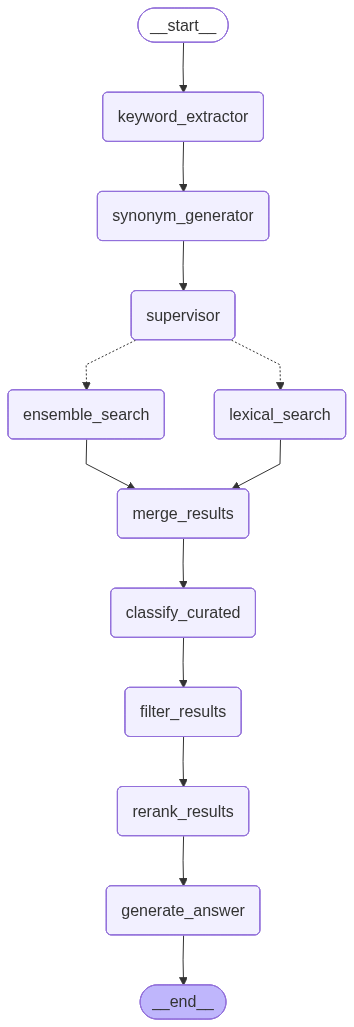

In [25]:
from IPython.display import Image, display

display(Image(orchestrator.get_graph().draw_mermaid_png()))

## 9. Test Queries

Three representative queries that exercise the two routing paths.  All use the default
`top_k=10`.  Pass `top_k=N` to `run_query` to get more or fewer results.

| Query | Expected route | Why |
|---|---|---|
| Natural language (deep learning) | `ensemble` | Natural language phrasing — default route |
| Keyword-only ("pytorch transformers") | `lexical` | Literally just keywords, no sentence structure |
| Conceptual (probability / Bayesian) | `ensemble` | Conceptual query — default route |

The helper function `run_query(query, top_k=10)` prints each pipeline stage so we can
inspect what the keyword extractor, synonym generator, supervisor, retriever(s), and
listwise reranker all produced.

In [26]:
def run_query(query: str, top_k: int = 10) -> dict:
    """Run a query through the orchestrator and display intermediate state.

    Args:
        query:  Natural language or keyword query.
        top_k:  Number of results to return after reranking (default 10).
                Retrievers always over-fetch (RETRIEVER_K candidates) internally.
    """
    print("=" * 70)
    print(f"QUERY: {query}  [top_k={top_k}]")
    print("=" * 70)

    initial_state: OrchestratorState = {
        "query":           query,
        "keywords":        [],
        "expansions":      [],
        "bm25_terms":      [],
        "route":           "",
        "include_curated": False,   # supervisor will overwrite this
        "bm25_results":    [],
        "vector_results":  [],
        "merged_results":  [],
        "top_k":           top_k,
        "answer":          "",
    }

    result = orchestrator.invoke(initial_state)

    print(f"\n--- Keywords extracted : {result['keywords']}")
    print(f"--- BM25 synonym terms : {result['bm25_terms'][:5]} ... ({len(result['bm25_terms'])} total)")
    print(f"--- Route chosen       : {result['route']}")
    print(f"--- Include curated    : {result['include_curated']}")
    print(f"--- BM25 hits          : {len(result['bm25_results'])}")
    print(f"--- Vector hits        : {len(result['vector_results'])}")
    print(f"--- Final results      : {len(result['merged_results'])} repos (top_k={top_k})")
    print()
    print("ANSWER:")
    print(result["answer"])
    print()

    return result

In [27]:
# Test 1 — Natural language query (expects 'ensemble')
result1 = run_query("What are some top deep learning libraries I have starred?")

QUERY: What are some top deep learning libraries I have starred?  [top_k=10]
[supervisor] route='ensemble'  include_curated=False  reason: The query is in natural language and seeks specific information about starred deep learning libraries, necessitating the ensemble strategy.
[classify_curated] 11/26 candidates flagged as curated lists
[filter_results] removed 11 curated-list repo(s), 15 candidates remaining
[reranker] 15 candidates → top 10 after reranking

--- Keywords extracted : ['deep learning', 'libraries']
--- BM25 synonym terms : ['neural networks', 'machine learning', 'artificial intelligence', 'reinforcement learning', 'semantic networks'] ... (19 total)
--- Route chosen       : ensemble
--- Include curated    : False
--- BM25 hits          : 26
--- Vector hits        : 0
--- Final results      : 10 repos (top_k=10)

ANSWER:
1. [microsoft/nni](https://github.com/microsoft/nni)  
   An open-source toolkit for automating machine learning lifecycle tasks like feature engineeri

In [28]:
# Test 2 — Keyword-only query (expects 'lexical')
result2 = run_query("pytorch transformers")

QUERY: pytorch transformers  [top_k=10]
[supervisor] route='lexical'  include_curated=False  reason: The query contains only a list of keywords without any natural language structure, so a lexical search strategy is suitable.
[classify_curated] 9/25 candidates flagged as curated lists
[filter_results] removed 9 curated-list repo(s), 16 candidates remaining
[reranker] 16 candidates → top 10 after reranking

--- Keywords extracted : ['pytorch', 'transformers']
--- BM25 synonym terms : ['torch', 'deep learning framework', 'tensor library', 'machine learning', 'neural networks'] ... (20 total)
--- Route chosen       : lexical
--- Include curated    : False
--- BM25 hits          : 25
--- Vector hits        : 0
--- Final results      : 10 repos (top_k=10)

ANSWER:
1. [huggingface/transformers](https://github.com/huggingface/transformers)  
   A model-definition framework for cutting-edge machine learning models including text, vision, audio, and multimodal models for both training and infer

In [29]:
# Test 3 — Conceptual / exploratory query (expects 'semantic' or 'both')
result3 = run_query("Do I have repos that help me understand probability and Bayesian reasoning?")

QUERY: Do I have repos that help me understand probability and Bayesian reasoning?  [top_k=10]
[supervisor] route='ensemble'  include_curated=False  reason: The query contains natural language phrasing requesting specific repositories related to a topic, so 'ensemble' is appropriate while including curated lists is not needed.
[classify_curated] 8/21 candidates flagged as curated lists
[filter_results] removed 8 curated-list repo(s), 13 candidates remaining
[reranker] 13 candidates → top 10 after reranking

--- Keywords extracted : ['probability', 'Bayesian', 'reasoning']
--- BM25 synonym terms : ['likelihood', 'chance', 'statistical chance', 'odds', 'uncertainty'] ... (24 total)
--- Route chosen       : ensemble
--- Include curated    : False
--- BM25 hits          : 21
--- Vector hits        : 0
--- Final results      : 10 repos (top_k=10)

ANSWER:
1. [pymc-devs/pymc](https://github.com/pymc-devs/pymc)  
   This repository offers tools for Bayesian Modeling and Probabilistic Programm